# Introdução

Meu objetivo com este projeto é aplicar conceitos de ciência de dados para se aproveitar da marcação à mercado nos títulos IPCA+ 2045 do Tesouro Direto. Minha abordagem consistirá em (1) importar e preparar os dados, (2) realizar análise exploratória e (3) criar um modelo de machine learning que possa adequadamente prever boas janelas para ganho com marcação à mercado.

## 1. Obtenção dos dados e preparação

1º Passo: Importar as bibliotecas e o conjunto de dados

In [26]:
# Importando bibliotecas e módulos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Importando os dados do csv na url
url = 'https://www.tesourotransparente.gov.br/ckan/dataset/df56aa42-484a-4a59-8184-7676580c81e3/resource/796d2059-14e9-44e3-80c9-2d9e30b405c1/download/PrecoTaxaTesouroDireto.csv'
df = pd.read_csv(url, sep=";")

df.head()

,Tipo Titulo,Data Vencimento,Data Base,Taxa Compra Manha,Taxa Venda Manha,PU Compra Manha,PU Venda Manha,PU Base Manha
0,Tesouro IPCA+,15/08/2024,13/11/2006,"7,91","7,99","418,01","412,57","412,40"
1,Tesouro IPCA+,15/05/2015,13/11/2006,"8,51","8,57","804,32","800,56","800,22"
2,Tesouro IGPM+ com Juros Semestrais,01/12/2006,13/11/2006,"11,26","11,28","2016,25","2016,23","2015,11"
3,Tesouro IGPM+ com Juros Semestrais,01/04/2008,13/11/2006,"9,17","9,19","1819,25","1818,81","1817,94"
4,Tesouro IGPM+ com Juros Semestrais,01/01/2031,13/11/2006,"8,08","8,18","2713,84","2688,67","2687,48"


2º Passo: Realizar operações de limpeza de dados, que incluirão:
- Renomear colunas
- Alterar tipo de dados 
- Filtrar linhas para que só retornem o Tesouro IPCA+ 2045
- Filtrar colunas desnecessárias para a análise

In [27]:
# Renomeando as colunas
df.columns = ['titulo', 'vencimento', 'data', 'tx_compra', 'tx_venda', 'pu_compra', 'pu_venda', 'pu_base']

# Transformando os tipos de dados
df['titulo'] = df['titulo'].apply(lambda x: x.replace("Tesouro ", ""))
df['vencimento'] = pd.to_datetime(df["vencimento"], format='%d/%m/%Y', errors='coerce')
df['data'] = pd.to_datetime(df["data"], format='%d/%m/%Y', errors='coerce')
df['tx_compra'] = pd.to_numeric(df['tx_compra'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float') / 100
df['tx_venda'] = pd.to_numeric(df['tx_venda'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float') / 100
df['pu_compra'] = pd.to_numeric(df['pu_compra'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float')
df['pu_venda'] = pd.to_numeric(df['pu_venda'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float')
df['pu_base'] = pd.to_numeric(df['pu_base'].apply(lambda x: x.replace(",", ".")), errors='coerce').astype('float')

# Limitando o dataset ao Tesouro IPCA+ 2045
df = df[(df['titulo'] == 'IPCA+') & (df['vencimento'] == '2045-05-15')]

# Excluindo as colunas desnecessárias
df.drop(['titulo', 'vencimento'], axis=1, inplace=True)

# Validando as transformações
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1698 entries, 1060 to 51963
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   data       1698 non-null   datetime64[ns]
 1   tx_compra  1698 non-null   float64       
 2   tx_venda   1698 non-null   float64       
 3   pu_compra  1698 non-null   float64       
 4   pu_venda   1698 non-null   float64       
 5   pu_base    1698 non-null   float64       
dtypes: datetime64[ns](1), float64(5)
memory usage: 92.9 KB


Com as transformações feitas, prosseguirei para a análise exploratória.

## 2. Análise Exploratória

A análise exploratória incluirá:

1. Visualização das distribuições das variáveis
2. Comparação de estatísticas descritivas numéricas
3. Visualização de dispersão
4. Análise de correlação
5. Análise de séries temporais

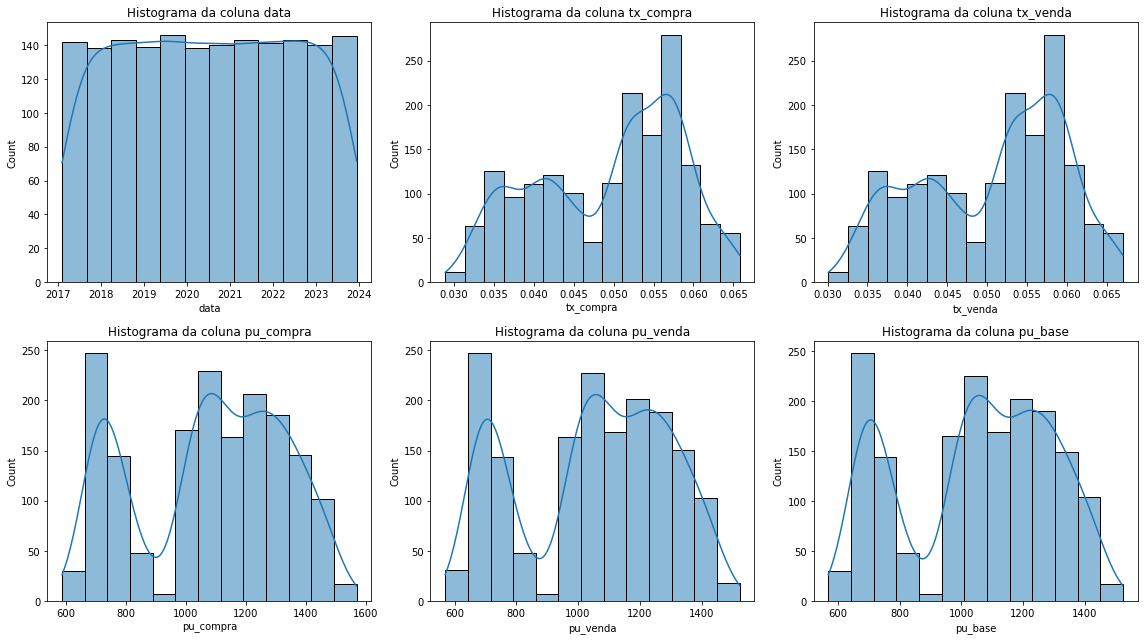

In [28]:
# Histograma para visualizar distribuição
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for i, coluna in enumerate(df.columns):
  ax = axes[i]
  sns.histplot(df[coluna], ax=ax, kde=True)
  ax.set_title(f'Histograma da coluna {coluna}')

plt.tight_layout()
plt.show()

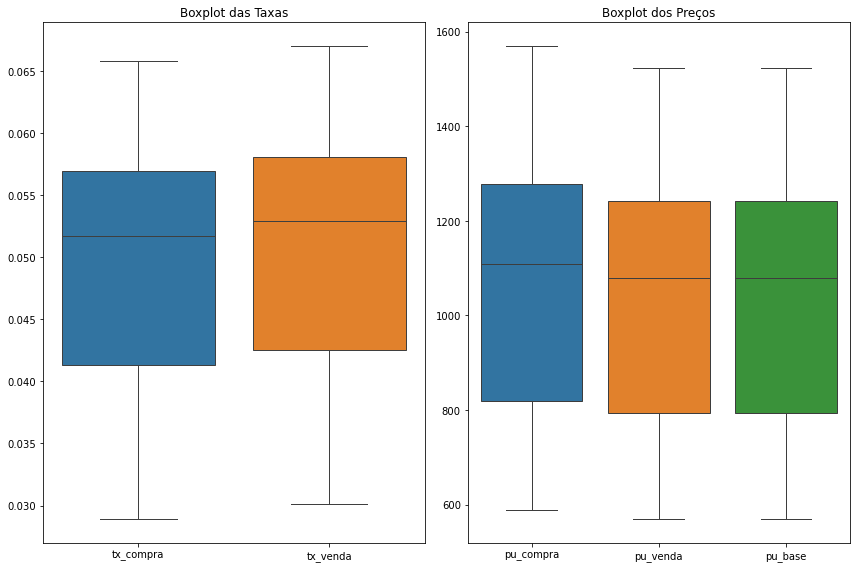

,tx_compra,tx_venda,pu_compra,pu_venda,pu_base
count,1698.000000,1698.000000,1698.000000,1698.000000,1698.000000
mean,0.049419,0.050619,1080.629629,1050.597244,1050.350453
std,0.009096,0.009096,246.838373,240.811200,240.746587
min,0.028900,0.030100,587.930000,569.670000,569.260000
25%,0.041300,0.042500,818.992500,794.460000,793.932500
50%,0.051700,0.052900,1108.245000,1078.860000,1078.810000
75%,0.056900,0.058100,1277.450000,1242.922500,1242.472500
max,0.065800,0.067000,1569.480000,1523.630000,1523.410000


In [29]:
# Boxplot para visualizar distribuição numericamente, seguido por df.describe()
df_taxas = df.iloc[:,1:3]
df_precos = df.iloc[:, 3:]

fig, axes = plt.subplots(1, 2, figsize=(12, 8))
axes = axes.ravel()

sns.boxplot(data=df_taxas, ax=axes[0])
sns.boxplot(data=df_precos, ax=axes[1])

axes[0].set_title("Boxplot das Taxas")
axes[1].set_title("Boxplot dos Preços")

plt.tight_layout()
plt.show()

df.describe()

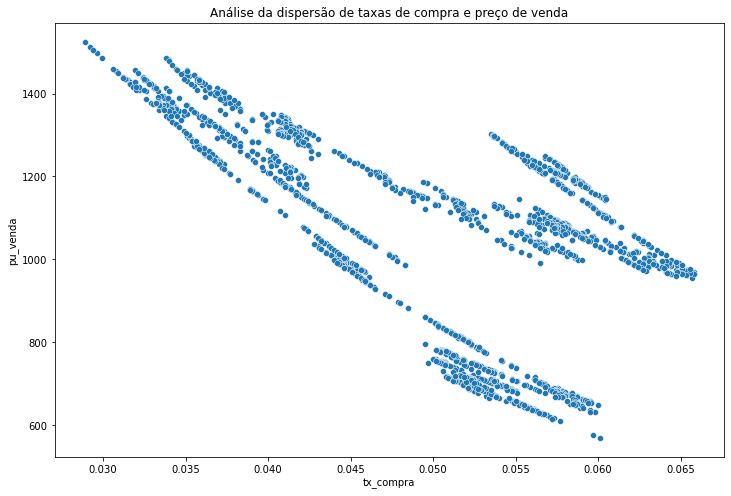

In [30]:
# Distribuição de Taxas X Preços
# Utilizarei taxas de compra e preços de compra pra facilitar a comparação

fig = plt.figure(figsize=(12,8))
sns.scatterplot(x=df['tx_compra'], y=df['pu_venda'])
plt.title('Análise da dispersão de taxas de compra e preço de venda')
plt.show()

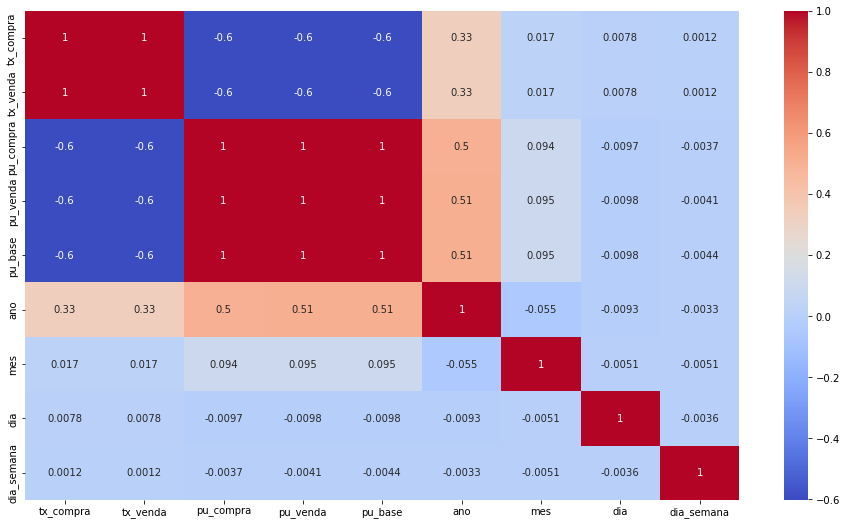

In [31]:
# Criando novas colunas de data
df['ano'] = df['data'].dt.year
df['mes'] = df['data'].dt.month
df['dia'] = df['data'].dt.day
df['dia_semana'] = df['data'].dt.dayofweek

# Criando matriz de correlação
df_corr = df.iloc[:,1:].corr(method='spearman')

# Plotando no heatmap
fig = plt.figure(figsize=(16,9))
sns.heatmap(df_corr, annot=True, cmap='coolwarm')
plt.show()